In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

import json
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
# Load the main.config.json file 

def load_main_config():
    with open("../config/main.config.json", "r") as f:
        return json.load(f)

main_config = load_main_config()
main_config

{'active_version': 'v2',
 'paths': {'model': 'models/v2/model_bundle.pkl',
  'thresholds': 'config/v2/threshold-config.json',
  'data_config': 'config/v2/data-config.json'},
 'data': {'filename': 'synthetic_ecomops_logs.csv'},
 's3': {'bucket': 'e-com-sla', 'prefix': 'anomaly-detection'},
 'flags': {'upload_to_s3': False, 'download_from_s3': False}}

In [3]:
def get_path(key, config):
    return "../" + config["paths"][key]

data_config_path = get_path("data_config", main_config)

with open(data_config_path, "r") as f:
    data_config = json.load(f)

data_config.keys()

dict_keys(['_meta', 'noise', 'system_dynamics', 'traffic_curve', 'operations', 'hourly_rules', 'anomaly_injection'])

In [4]:
np.random.seed(42)

def add_noise(value, pct):
    return value * (1 + np.random.uniform(-pct, pct))

def random_in_range(low, high, pct):
    base = np.random.uniform(low, high)
    return add_noise(base, pct)

def compute_hour_factor(hour, config):
    curve = config["traffic_curve"]

    base = curve["base"]

    # Evening peak (circular)
    ep = curve["evening_peak"]
    d = min(abs(hour - ep["center"]), 24 - abs(hour - ep["center"]))
    evening = ep["amplitude"] * np.exp(-(d**2) / ep["spread"])

    # Midday peak
    mp = curve["midday_peak"]
    midday = mp["amplitude"] * np.exp(-((hour - mp["center"])**2) / mp["spread"])

    # Early dip
    ed = curve["early_dip"]
    dip = ed["amplitude"] * np.exp(-((hour - ed["center"])**2) / ed["spread"])

    return base + evening + midday - dip

def apply_hourly_rules(cmd, hour, values, hourly_rules):
    hour_str = str(hour)

    if hour_str in hourly_rules and cmd in hourly_rules[hour_str]:
        rules = hourly_rules[hour_str][cmd]

        for key, multiplier in rules.items():
            field = key.replace("_multiplier", "")

            # 🚨 ONLY allow latency + failure rules
            if field in ["success_rt_avg", "fail_rt_avg", "fail_vol"]:
                if field in values:
                    values[field] *= multiplier

    return values

def apply_load_dynamics(op, values, cfg, config):
    """
    Apply realistic system load behavior:
    Volume → Latency → Failures
    """

    baseline_vol = cfg["success_vol"]

    if baseline_vol <= 0:
        return values

    # ----------------------------
    # 1. Compute load
    # ----------------------------
    load_factor = values["success_vol"] / baseline_vol
    load_delta = load_factor - 1

    # Clamp extreme spikes
    load_delta = min(load_delta, 3)

    latency_factor = config["system_dynamics"]["latency_increase_factor"]
    failure_factor = config["system_dynamics"]["failure_increase_factor"]

    # ----------------------------
    # 2. Apply effects
    # ----------------------------

    # Latency increases with load
    values["success_rt_avg"] *= (1 + latency_factor * load_delta)
    values["fail_rt_avg"] *= (1 + latency_factor * load_delta)

    # Failures increase more aggressively non linearly
    values["fail_vol"] *= (1 + failure_factor * (load_factor ** 1.3 - 1))

    # ----------------------------
    # 3. Safety clamps
    # ----------------------------
    values["success_rt_avg"] = max(values["success_rt_avg"], 1)
    values["fail_rt_avg"] = max(values["fail_rt_avg"], 1)
    values["fail_vol"] = max(values["fail_vol"], 0)

    return values

In [5]:
def generate_data(start_date, hours, config):

    RANDOMNESS = config["noise"]
    operations_config = config["operations"]
    hourly_rules = config["hourly_rules"]

    data = []
    current = start_date

    for _ in range(hours):
        hour = current.hour

        # compute hour factor ONCE per hour
        hour_factor = compute_hour_factor(hour, config)

        for op, cfg in operations_config.items():

            base_vol = cfg["success_vol"]

            # ----------------------------
            # 1. TRAFFIC (CURVE-BASED)
            # ----------------------------
            success_vol = base_vol * hour_factor
            
            # ----------------------------
            # 2. ADD NOISE
            # ----------------------------
            values = {
                "success_vol": add_noise(success_vol, RANDOMNESS["success_vol_std_pct"]),
                "fail_vol": add_noise(cfg["fail_vol"], RANDOMNESS["fail_vol_std_pct"]),
                "success_rt_avg": random_in_range(*cfg["success_rt_avg"], RANDOMNESS["latency_std_pct"]),
                "fail_rt_avg": random_in_range(*cfg["fail_rt_avg"], RANDOMNESS["latency_std_pct"])
            }
            
            # ----------------------------
            # 3. LOAD DYNAMICS
            # ----------------------------
            values = apply_load_dynamics(op, values, cfg, config)

            # ----------------------------
            # 4. HOURLY RULES (EXCEPTIONS ONLY)
            # ----------------------------
            values = apply_hourly_rules(op, hour, values, hourly_rules)
            # ----------------------------
            # 5. FINAL OUTPUT
            # ----------------------------
            data.append({
                "timestamp": current,
                "operation": op,
                "success_vol": int(values["success_vol"]),
                "success_rt_avg": round(values["success_rt_avg"], 3),
                "fail_vol": int(values["fail_vol"]),
                "fail_rt_avg": round(values["fail_rt_avg"], 3)
            })

        current += timedelta(hours=1)

    return pd.DataFrame(data)

In [6]:
df = generate_data(
    start_date=datetime(2025, 1, 1),
    hours=24 * 90,   
    config=data_config
)

df.head(50)

,timestamp,operation,success_vol,success_rt_avg,fail_vol,fail_rt_avg
0,2025-01-01 00:00:00,browse_products,121586,21.479,617,5.404
1,2025-01-01 00:00:00,view_cart,26345,30.134,436,10.757
2,2025-01-01 00:00:00,add_to_cart,24172,47.051,585,31.103
3,2025-01-01 00:00:00,checkout,8301,179.964,275,107.498
4,2025-01-01 00:00:00,payment,6288,203.375,294,174.204
5,2025-01-01 01:00:00,browse_products,102216,11.429,378,9.970
6,2025-01-01 01:00:00,view_cart,22585,29.370,270,10.378
7,2025-01-01 01:00:00,add_to_cart,13291,46.756,573,26.504
8,2025-01-01 01:00:00,checkout,6655,245.887,225,178.223
9,2025-01-01 01:00:00,payment,5091,154.318,273,98.375


In [7]:
df.describe()

,timestamp,success_vol,success_rt_avg,fail_vol,fail_rt_avg
count,10800,10800.000000,10800.000000,10800.000000,10800.000000
mean,2025-02-14 23:30:00,42825.062963,117.669475,469.736759,76.022221
min,2025-01-01 00:00:00,1461.000000,7.591000,109.000000,3.768000
25%,2025-01-23 11:45:00,8874.000000,25.067750,294.000000,12.688000
50%,2025-02-14 23:30:00,15862.000000,61.045000,422.000000,35.147000
75%,2025-03-09 11:15:00,45306.250000,193.704000,605.000000,135.686500
max,2025-03-31 23:00:00,260433.000000,707.763000,1369.000000,351.950000
std,NaN,58897.847360,117.559714,232.046562,77.191255


In [8]:
df.groupby("operation")["success_vol"].mean()

operation
add_to_cart         23356.709259
browse_products    139558.515741
checkout             9366.468056
payment              6971.074537
view_cart           34872.547222
Name: success_vol, dtype: float64

<Axes: xlabel='timestamp'>

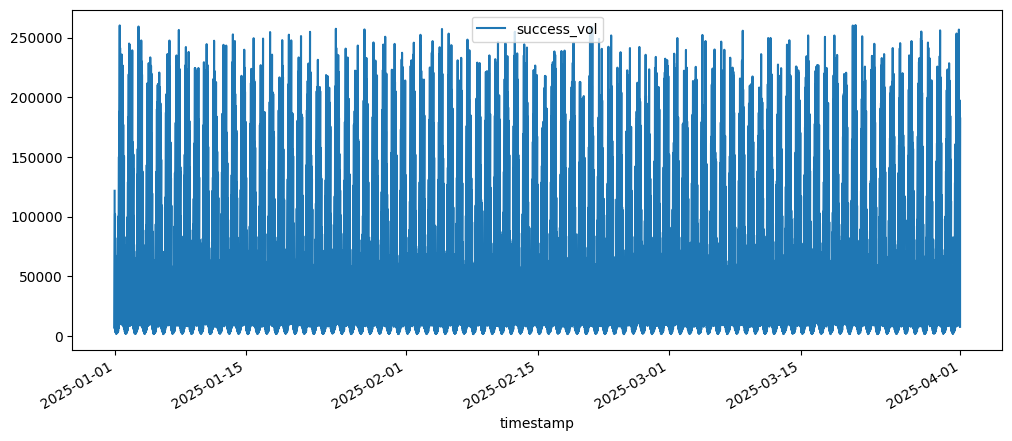

In [9]:
df.plot(x="timestamp", y="success_vol", figsize=(12,5))

In [10]:
output_path = "../data/raw/synthetic_ecomop_logs_1.csv"
df.to_csv(output_path, index=False)

print(f"Saved to {output_path}")

Saved to ../data/raw/synthetic_ecomop_logs_1.csv


<Axes: xlabel='hour'>

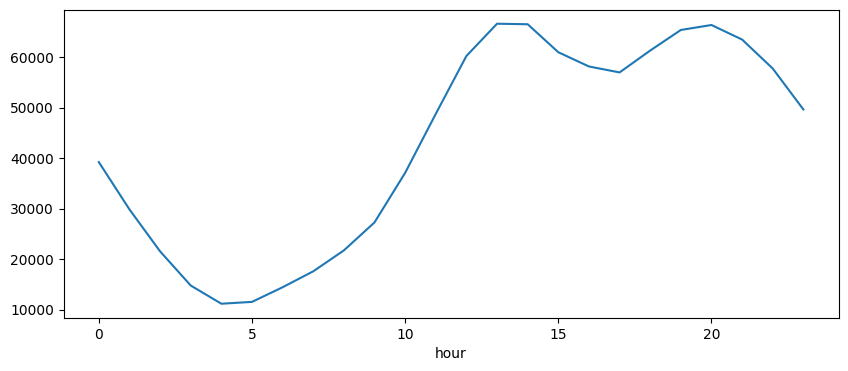

In [11]:
df["hour"] = df["timestamp"].dt.hour
df.groupby("hour")["success_vol"].mean().plot(figsize=(10,4))

In [12]:
print(df.head(96))

             timestamp        operation  success_vol  success_rt_avg  \
0  2025-01-01 00:00:00  browse_products       121586          21.479   
1  2025-01-01 00:00:00        view_cart        26345          30.134   
2  2025-01-01 00:00:00      add_to_cart        24172          47.051   
3  2025-01-01 00:00:00         checkout         8301         179.964   
4  2025-01-01 00:00:00          payment         6288         203.375   
..                 ...              ...          ...             ...   
91 2025-01-01 18:00:00        view_cart        42174          33.129   
92 2025-01-01 18:00:00      add_to_cart        33947          89.019   
93 2025-01-01 18:00:00         checkout        14660         290.658   
94 2025-01-01 18:00:00          payment         9380         372.277   
95 2025-01-01 19:00:00  browse_products       213514          20.157   

    fail_vol  fail_rt_avg  hour  
0        617        5.404     0  
1        436       10.757     0  
2        585       31.103     0  